### AI-Augmented Circuit Parameter Design for Buck Converters 
 * Basic exploratory data analysis for the dataset
 * Stage 1: Build lookup tables for the considered inductors and capacitors
 * Stage 2: Train data-driven surrogate models for efficiency, voltage ripple, and current ripple
   1. Feedforward NN with BatchNorm
   2. Classific ML: Ridge regression, SVM, Bayesian regression
   3. Ensemble learning: Random forest, XGBoost
 * Stage 3: Meta-heuristic algorithms interact with data-driven models to optimize buck converter performances
   1. Compare PSO and GA
   2. Multi-Objective design with non-dominated sorting
 * Refer to paper, "X. Li, X. Zhang, F. Lin and F. Blaabjerg, "Artificial-Intelligence-Based Design for Circuit Parameters of Power Converters," in IEEE Transactions on Industrial Electronics, vol. 69, no. 11, pp. 11144-11155, Nov. 2022, doi: 10.1109/TIE.2021.3088377.", for more details 

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 Basic Exploratory Data Analysis
* Correlation analysis
* t-SNE
* Outlier detection

In [2]:
# Enable inline plotting for Jupyter notebooks
%matplotlib inline

# Import necessary libraries
import os
import sys
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset from CSV file
df = pd.read_csv("total_100W_12V.csv")

# Drop the unnecessary column 'Unnamed: 0' (often created by pandas when saving CSVs)
df = df.drop(columns=['Unnamed: 0'])

# Print the number of rows in the dataframe
print(len(df))

# Convert the dataframe to a numpy array of floats for further processing
DATA = df.values.astype(float)

# Get the indices of the input features: frequency (f), inductance (L), and capacitance (C)
input_indices = list(map(lambda x: list(df.columns).index(x), ['f', 'L', 'C']))

# Get the indices for losses in switch 1: pl_s1 (left), pr_s1 (right)
total_loss_indices = list(map(lambda x: list(df.columns).index(x), ['pin', 'pout', 'pfe']))

# Get the indices for inductor current ripple: ilmax (max current), ilmin (min current)
i_ripple_indices = list(map(lambda x: list(df.columns).index(x), ['ilmax', 'ilmin']))

# Get the indices for output voltage ripple: vmax (max voltage), vmin (min voltage)
v_ripple_indices = list(map(lambda x: list(df.columns).index(x), ['vmax', 'vmin']))

# Print all the indices for verification
# print(input_indices, loss_s1_indices, loss_s2_indices, loss_L_indices, loss_C_indices, i_ripple_indices, v_ripple_indices)

# Define input variables and target variables for modeling

# Input variables: frequency (f), inductance (L), capacitance (C)
X = DATA[:, input_indices]

# Target 1: Total power loss (custom calculation as per instructions)
# Check the power flow direction
y_loss = DATA[:, total_loss_indices[0]] - DATA[:, total_loss_indices[1]] + DATA[:, total_loss_indices[2]]

# Target 2: Inductor current ripple ratio ((ilmax - ilmin) / (ilmax + ilmin) * 2)
ilmax = DATA[:, i_ripple_indices[0]]
ilmin = DATA[:, i_ripple_indices[1]]
y_current_ripple = (ilmax - ilmin) / (ilmax + ilmin) * 2

# Target 3: Output voltage ripple ratio ((vmax - vmin) / (vmax + vmin) * 2)
vmax = DATA[:, v_ripple_indices[0]]
vmin = DATA[:, v_ripple_indices[1]]
y_voltage_ripple = (vmax - vmin) / (vmax + vmin) * 2

# Print shapes for verification
print("X shape:", X.shape)
print("y_loss shape:", y_loss.shape)
print("y_current_ripple shape:", y_current_ripple.shape)
print("y_voltage_ripple shape:", y_voltage_ripple.shape)


2628
X shape: (2628, 3)
y_loss shape: (2628,)
y_current_ripple shape: (2628,)
y_voltage_ripple shape: (2628,)


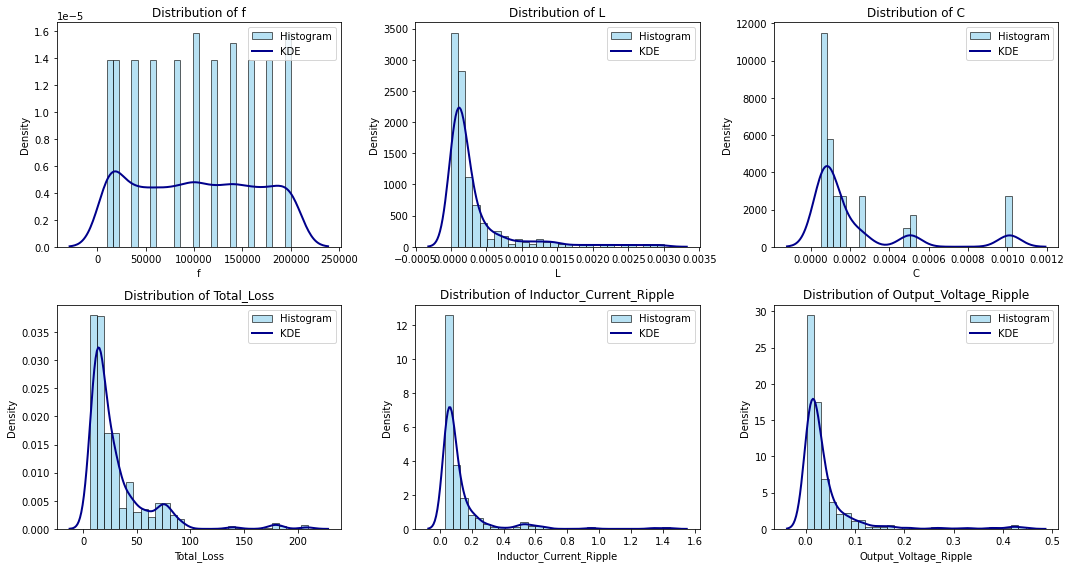

In [3]:
# Plot histograms and KDEs for input and output variables

import seaborn as sns

input_names = ['f', 'L', 'C']
output_names = ['Total_Loss', 'Inductor_Current_Ripple', 'Output_Voltage_Ripple']

# Prepare data for plotting
plot_data = np.column_stack([X, y_loss, y_current_ripple, y_voltage_ripple])
plot_labels = input_names + output_names

plt.figure(figsize=(15, 8))
for i, label in enumerate(plot_labels):
    plt.subplot(2, 3, i+1)
    # Plot histogram
    plt.hist(plot_data[:, i], bins=30, color='skyblue', edgecolor='black', alpha=0.6, density=True, label='Histogram')
    # Plot KDE
    sns.kdeplot(plot_data[:, i], color='darkblue', linewidth=2, label='KDE')
    plt.title(f"Distribution of {label}")
    plt.xlabel(label)
    plt.ylabel("Density")
    plt.legend()
plt.tight_layout()
plt.show()


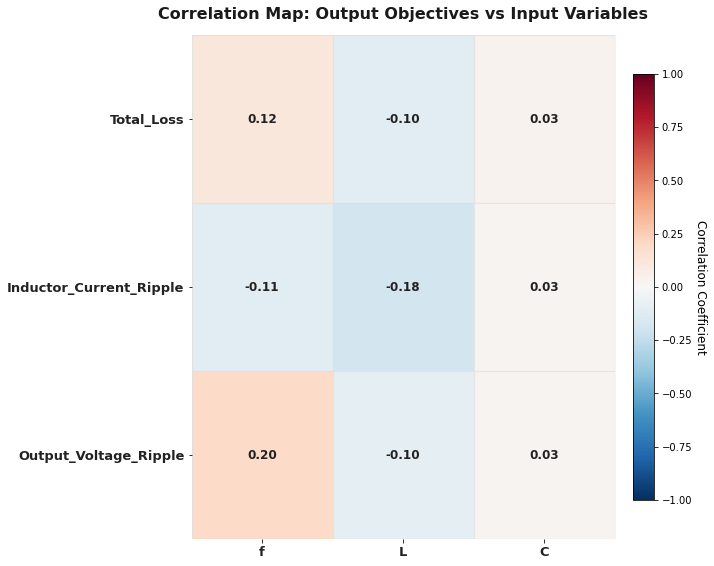

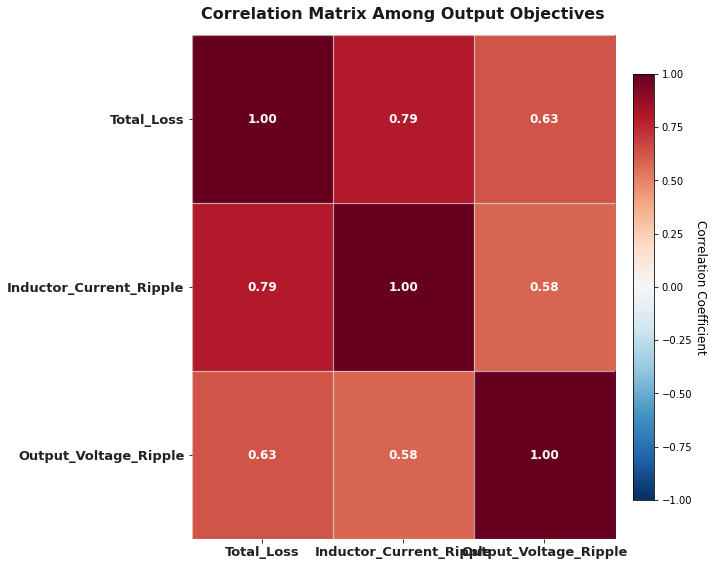

In [4]:
# Plot the correlation map for output objectives with respect to input variables

# Create DataFrame for input variables and output objectives
input_names = ['f', 'L', 'C']
output_names = ['Total_Loss', 'Inductor_Current_Ripple', 'Output_Voltage_Ripple']

corr_df = pd.DataFrame(
    np.column_stack([X, y_loss, y_current_ripple, y_voltage_ripple]),
    columns=input_names + output_names
)

# Compute correlation matrix: only output objectives (rows) vs input variables (columns)
corr_matrix = corr_df[output_names].corrwith(corr_df[input_names], axis=0)
# But corrwith gives a Series per output, so we want a DataFrame of shape (outputs, inputs)
corr_matrix = corr_df[input_names + output_names].corr().loc[output_names, input_names]

# Plot the heatmap
plt.figure(figsize=(10, 8))
im = plt.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colorbar with label
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Correlation Coefficient', rotation=270, labelpad=15, fontsize=12)

# Professional styling for correlation heatmap

# Set ticks and labels with enhanced styling
plt.xticks(
    range(len(input_names)), input_names, rotation=0, fontsize=13, fontweight='semibold', color='#222222'
)
plt.yticks(
    range(len(output_names)), output_names, fontsize=13, fontweight='semibold', color='#222222'
)

# Draw grid lines for clarity
plt.gca().set_xticks(np.arange(-.5, len(input_names), 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(output_names), 1), minor=True)
plt.grid(which='minor', color='#e0e0e0', linestyle='-', linewidth=1.2, alpha=0.7)
plt.gca().tick_params(which='minor', bottom=False, left=False)

# Annotate correlation coefficients with professional formatting
for i in range(len(output_names)):
    for j in range(len(input_names)):
        value = corr_matrix.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha='center', va='center',
            color='white' if abs(value) > 0.5 else '#222222',
            fontsize=12, fontweight='bold', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.18')
        )

plt.title(
    "Correlation Map: Output Objectives vs Input Variables",
    fontsize=16, fontweight='bold', pad=16, color='#1a1a1a'
)
plt.tight_layout(pad=1.2)
plt.gca().spines[:].set_visible(False)
plt.show()


# Plot the correlation matrix among the output objectives themselves

# Compute correlation matrix for output objectives
objectives_corr = corr_df[output_names].corr()

plt.figure(figsize=(10, 8))
im = plt.imshow(objectives_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

# Add colorbar with label
cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
cbar.ax.set_ylabel('Correlation Coefficient', rotation=270, labelpad=15, fontsize=12)

# Set ticks and labels
plt.xticks(
    range(len(output_names)), output_names, rotation=0, fontsize=13, fontweight='semibold', color='#222222'
)
plt.yticks(
    range(len(output_names)), output_names, fontsize=13, fontweight='semibold', color='#222222'
)

# Draw grid lines for clarity
plt.gca().set_xticks(np.arange(-.5, len(output_names), 1), minor=True)
plt.gca().set_yticks(np.arange(-.5, len(output_names), 1), minor=True)
plt.grid(which='minor', color='#e0e0e0', linestyle='-', linewidth=1.2, alpha=0.7)
plt.gca().tick_params(which='minor', bottom=False, left=False)

# Annotate correlation coefficients
for i in range(len(output_names)):
    for j in range(len(output_names)):
        value = objectives_corr.iloc[i, j]
        plt.text(
            j, i, f"{value:.2f}",
            ha='center', va='center',
            color='white' if abs(value) > 0.5 else '#222222',
            fontsize=12, fontweight='bold', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round,pad=0.18')
        )

plt.title(
    "Correlation Matrix Among Output Objectives",
    fontsize=16, fontweight='bold', pad=16, color='#1a1a1a'
)
plt.tight_layout(pad=1.2)
plt.gca().spines[:].set_visible(False)
plt.show()



In [5]:
from scipy.stats import zscore

# Compute z-scores for all objectives
z_loss = zscore(y_loss)
z_current_ripple = zscore(y_current_ripple)
z_voltage_ripple = zscore(y_voltage_ripple)

# Define a threshold for outlier detection (commonly 3)
threshold = 3

# Find outlier indices for each objective
outliers_loss = np.where(np.abs(z_loss) > threshold)[0]
outliers_current_ripple = np.where(np.abs(z_current_ripple) > threshold)[0]
outliers_voltage_ripple = np.where(np.abs(z_voltage_ripple) > threshold)[0]

# Combine all outlier indices (if any objective is unsatisfied, filter out)
all_outliers = np.unique(
    np.concatenate([outliers_loss, outliers_current_ripple, outliers_voltage_ripple])
)

print("Number of outliers in total power loss:", len(outliers_loss))
print("Number of outliers in inductor current ripple:", len(outliers_current_ripple))
print("Number of outliers in output voltage ripple:", len(outliers_voltage_ripple))
print("Total number of rows to filter out (any objective):", len(all_outliers))

# Filter out the outliers from all relevant arrays
X = np.delete(X, all_outliers, axis=0)
y_loss = np.delete(y_loss, all_outliers, axis=0)
y_current_ripple = np.delete(y_current_ripple, all_outliers, axis=0)
y_voltage_ripple = np.delete(y_voltage_ripple, all_outliers, axis=0)
# If you have other arrays (e.g., all_data, tsne_results), filter them similarly if needed

print("Shapes after outlier removal:")
print("X shape:", X.shape)
print("y_loss shape:", y_loss.shape)
print("y_current_ripple shape:", y_current_ripple.shape)
print("y_voltage_ripple shape:", y_voltage_ripple.shape)



Number of outliers in total power loss: 56
Number of outliers in inductor current ripple: 45
Number of outliers in output voltage ripple: 68
Total number of rows to filter out (any objective): 124
Shapes after outlier removal:
X shape: (2504, 3)
y_loss shape: (2504,)
y_current_ripple shape: (2504,)
y_voltage_ripple shape: (2504,)


#### 2 Stage 1: Build Lookup Tables for the Considered Inductors and Capacitors
* Inductor core: Toroidal TAF-200 series
* Capacitor series: 25 V Nippon KZE series

In [6]:
import numpy as np
import pandas as pd
from itertools import product

# Standard capacitor values in Farads
# The capacitance list is from the cap series 25-V Nippon KZE
C_List = [27e-6, 47e-6, 56e-6, 100e-6, 220e-6, 330e-6, 470e-6, 680e-6]

def input_staircase_C(C_List, maximum=.5e-3):
    """
    Generate a staircase of capacitor combinations up to a maximum value.
    
    Args:
        C_List (list): List of capacitor values in Farads
        maximum (float): Maximum total capacitance value in Farads (default: 0.5mF)
    
    Returns:
        tuple: (sorted_capacitances, capacitor_combinatioans)
            - sorted_capacitances: Array of possible total capacitance values
            - capacitor_combinations: List of capacitor combinations for each total value
    """
    staircase = []
    staircase_specific = []
    
    for C in C_List:
        # Calculate number of capacitors needed to reach maximum
        num_repeat = int(np.ceil(maximum / C))
        
        # Generate combinations for each multiplier
        for multiplier in range(1, num_repeat):
            sum_item = round(multiplier * C, 6)
            
            # Add new combination if not exists
            if sum_item not in staircase:
                staircase.append(sum_item)
                staircase_specific.append([C] * multiplier)
            # Update existing combination if more efficient
            else:
                index = staircase.index(sum_item)
                if len(staircase_specific[index]) > multiplier:
                    staircase_specific[index] = [C] * multiplier
    
    # Sort results by capacitance value
    sorted_indices = np.argsort(staircase)
    sorted_capacitances = np.sort(staircase)
    sorted_combinations = [staircase_specific[i] for i in sorted_indices]
    
    return sorted_capacitances, sorted_combinations


# test the function input_staircase_C
# sorted_capacitances, sorted_combinations = input_staircase_C(C_List, maximum=.5e-3)
# print(sorted_capacitances)
# print(sorted_combinations)

In [7]:
def input_staircase_L(maximum=1.0e-3):
    # four toroidal inductor cores are available
    # information below are obtained from magnetic core datasheets 
    VolL = [2.035009053, 6.308373812, 9.493814459, 12.85509555]
    Ae = [24.13e-6, 68.82e-6, 92.685e-6, 93.795e-6]
    AL = [46, 93, 116, 96]
    Nmax_list = [56, 74, 93, 162] # decided by core filling coefficient
    core_series = ["T-80-75-200", "T-106-75-200", "T-131-75-200", "T-150-75-200"]

    L_list = [[] for _ in range(len(core_series))]
    VolL_list = [[] for _ in range(len(core_series))]
    N_list = [[] for _ in range(len(core_series))]
    core_list = [[] for _ in range(len(core_series))]

    for i, al in enumerate(AL):
        # Calculate maximum turns (assuming 1000 turns as practical limit)
        N_max = Nmax_list[i]
        for j in range(N_max):
            L_temp = round(np.power((j+1)/1e3, 2) * al*1e-3, 9)
            L_list[i].append(L_temp)
            VolL_list[i].append(VolL[i])
            N_list[i].append(j+1)
            core_list[i].append(core_series[i])

    L_sep = [item[-1] for item in L_list]
    L_list_available = []
    VolL_list_available = []
    N_list_available = []
    core_list_available = []
    for i in range(len(core_series)):
        for j in range(len(L_list[i])):
            if i > 0:
                if L_list[i][j] <= L_list[i-1][-1]: continue 
            L_list_available.append(L_list[i][j])
            VolL_list_available.append(VolL_list[i][j])
            N_list_available.append(N_list[i][j])
            core_list_available.append(core_list[i][j])

    return L_list_available, VolL_list_available, N_list_available, core_list_available

            
# L_list_available, VolL_list_available, N_list_available, core_list_available = input_staircase_L()

In [8]:
VolL = [2.035009053, 6.308373812, 9.493814459, 12.85509555] # The volume of a single inductor
Volume_C = {27e-6: 0.137444679, 47e-6: 0.215984495, 56e-6: 0.218207172, 
                 100e-6: 0.342896984, 220e-6: 0.578053048, 330e-6: 0.753982237, 
                 470e-6: 1.256637061, 680e-6: 1.570796327}  # The volume of a single capacitor
C_available, C_combinations = input_staircase_C(C_List, maximum=1e-3)
L_list_available, VolL_list_available, N_list_available, core_list_available = input_staircase_L()

# Get min/max values from data points
# This defines the feasible range of the input variables (taht NN is defined on)
L_min, C_min = X[:, 1].min(), X[:, 2].min()
L_max, C_max = X[:, 1].max(), X[:, 2].max()

# Filter L values to be within feasible range
L_mask = (L_list_available >= L_min) & (L_list_available <= L_max)
L_list_filtered = np.array(L_list_available)[L_mask]
VolL_list_filtered = np.array(VolL_list_available)[L_mask]
N_list_filtered = np.array(N_list_available)[L_mask]
core_list_filtered = np.array(core_list_available)[L_mask]

# Filter C values to be within feasible range
C_mask = (C_available >= C_min) & (C_available <= C_max)
C_available_filtered = np.array(C_available)[C_mask]
C_combinations_filtered = [C_combinations[i] for i in range(len(C_combinations)) if C_mask[i]]

# Update the original lists with filtered values
L_list_available = L_list_filtered.tolist()
VolL_list_available = VolL_list_filtered.tolist()
N_list_available = N_list_filtered.tolist()
core_list_available = core_list_filtered.tolist()
C_available = C_available_filtered.tolist()
C_combinations = C_combinations_filtered

#### 3 Stage 2: Train Data-Driven Surrogate Models for Efficiency, Voltage Ripple, and Current Ripple
   1. Feedforward NN with BatchNorm
   2. Classific ML: Ridge regression, SVM, Bayesian regression
   3. Ensemble learning: Random forest, XGBoost
   4. Objective: Predict total power loss given fs, L, and C

##### 3.1 FNN with BatchNorm

In [9]:
from sklearn.model_selection import train_test_split

# Prepare the input features (X) and targets (y)
# Here, we will use y_loss, y_current_ripple, y_voltage_ripple as targets for different models
# For demonstration, let's prepare for y_loss; you can repeat for other targets as needed

# First, split into train+val and test sets (e.g., 80% train+val, 20% test)
X_trainval, X_test, y_loss_trainval, y_loss_test, y_current_ripple_trainval, y_current_ripple_test, y_voltage_ripple_trainval, y_voltage_ripple_test = train_test_split(
    X, y_loss, y_current_ripple, y_voltage_ripple, test_size=0.2, random_state=42
)

# Then, split train+val into train and val sets (e.g., 75% train, 25% val of train+val, which is 60% train, 20% val overall)
X_train, X_val, y_loss_train, y_loss_val, y_current_ripple_train, y_current_ripple_val, y_voltage_ripple_train, y_voltage_ripple_val = train_test_split(
    X_trainval, y_loss_trainval, y_current_ripple_trainval, y_voltage_ripple_trainval, test_size=0.25, random_state=42
)

print("Train set shape:", X_train.shape)
print("Validation set shape:", X_val.shape)
print("Test set shape:", X_test.shape)


Train set shape: (1502, 3)
Validation set shape: (501, 3)
Test set shape: (501, 3)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import copy

# Scale both the input variables and the output (objective)
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit scalers on training data and transform all splits
X_train_scaled = X_scaler.fit_transform(X_train)
X_val_scaled = X_scaler.transform(X_val)
X_test_scaled = X_scaler.transform(X_test)

y_train_scaled = y_scaler.fit_transform(y_loss_train.reshape(-1, 1))
y_val_scaled = y_scaler.transform(y_loss_val.reshape(-1, 1))
y_test_scaled = y_scaler.transform(y_loss_test.reshape(-1, 1))

# Convert data to torch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32)

# Apply Feedforward Neural Network (FNN) with Batch Normalization

# Define a new model class with batch normalization (already present in FeedforwardNN)
class FeedforwardNN_BN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super(FeedforwardNN_BN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# Instantiate the new model
input_dim = 3
model_bn = FeedforwardNN_BN(input_dim, 64)
criterion_bn = nn.MSELoss()
optimizer_bn = optim.Adam(model_bn.parameters(), lr=2e-3)
scheduler_bn = optim.lr_scheduler.StepLR(optimizer_bn, step_size=200, gamma=0.5)

num_epochs_bn = 1000
train_losses_bn = []
val_losses_bn = []
test_losses_bn = []

# For tracking the best model (minimal validation loss)
best_val_loss_bn = float('inf')
best_model_state_bn = None
best_epoch_bn = -1

for epoch in range(num_epochs_bn):
    # Training
    model_bn.train()
    optimizer_bn.zero_grad()
    outputs_bn = model_bn(X_train_tensor)
    loss_bn = criterion_bn(outputs_bn, y_train_tensor)
    loss_bn.backward()
    optimizer_bn.step()
    train_losses_bn.append(loss_bn.item())

    # Validation
    model_bn.eval()
    with torch.no_grad():
        val_outputs_bn = model_bn(X_val_tensor)
        val_loss_bn = criterion_bn(val_outputs_bn, y_val_tensor)
        val_losses_bn.append(val_loss_bn.item())

        test_outputs_bn = model_bn(X_test_tensor)
        test_loss_bn = criterion_bn(test_outputs_bn, y_test_tensor)
        test_losses_bn.append(test_loss_bn.item())

    # Save the best model (minimal validation loss)
    if val_loss_bn.item() < best_val_loss_bn:
        best_val_loss_bn = val_loss_bn.item()
        best_model_state_bn = copy.deepcopy(model_bn.state_dict())
        best_epoch_bn = epoch

    scheduler_bn.step()

    if (epoch+1) % 50 == 0 or epoch == 0:
        current_lr_bn = optimizer_bn.param_groups[0]['lr']
        print(f"[BN] Epoch {epoch+1}/{num_epochs_bn} | Train Loss: {loss_bn.item():.4f} | Val Loss: {val_loss_bn.item():.4f} | Test Loss: {test_loss_bn.item():.4f} | LR: {current_lr_bn:.6f}")

# After training, load the best model (with minimal validation loss)
if best_model_state_bn is not None:
    model_bn.load_state_dict(best_model_state_bn)
    print(f"\nBest model loaded from epoch {best_epoch_bn+1} with minimal validation loss: {best_val_loss_bn:.6f}")


[BN] Epoch 1/1000 | Train Loss: 1.3703 | Val Loss: 1.0592 | Test Loss: 0.9871 | LR: 0.002000
[BN] Epoch 50/1000 | Train Loss: 0.0729 | Val Loss: 0.1753 | Test Loss: 0.2061 | LR: 0.002000
[BN] Epoch 100/1000 | Train Loss: 0.0694 | Val Loss: 0.0889 | Test Loss: 0.1119 | LR: 0.002000
[BN] Epoch 150/1000 | Train Loss: 0.0716 | Val Loss: 0.0984 | Test Loss: 0.1213 | LR: 0.002000
[BN] Epoch 200/1000 | Train Loss: 0.0615 | Val Loss: 0.0770 | Test Loss: 0.0972 | LR: 0.001000
[BN] Epoch 250/1000 | Train Loss: 0.0521 | Val Loss: 0.0706 | Test Loss: 0.0859 | LR: 0.001000
[BN] Epoch 300/1000 | Train Loss: 0.0392 | Val Loss: 0.0692 | Test Loss: 0.0790 | LR: 0.001000
[BN] Epoch 350/1000 | Train Loss: 0.0373 | Val Loss: 0.0648 | Test Loss: 0.0698 | LR: 0.001000
[BN] Epoch 400/1000 | Train Loss: 0.0338 | Val Loss: 0.0534 | Test Loss: 0.0657 | LR: 0.000500
[BN] Epoch 450/1000 | Train Loss: 0.0239 | Val Loss: 0.0484 | Test Loss: 0.0542 | LR: 0.000500
[BN] Epoch 500/1000 | Train Loss: 0.0242 | Val Loss: 

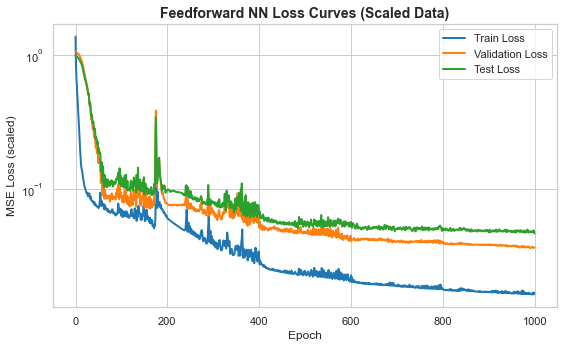

In [11]:
# Optionally, plot the losses
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("notebook")
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.plot(train_losses_bn, label='Train Loss', linewidth=2)
plt.plot(val_losses_bn, label='Validation Loss', linewidth=2)
plt.plot(test_losses_bn, label='Test Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('MSE Loss (scaled)', fontsize=12)
plt.yscale('log')
plt.legend(fontsize=11, frameon=True)
plt.title('Feedforward NN Loss Curves (Scaled Data)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [12]:
# XGBoost regression on the same efficiency (power loss) modeling problem, with early stopping on validation set
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Use the same scaled data as the FNN for fair comparison
xgb_loss = XGBRegressor(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0,
)

xgb_loss.fit(
    X_train_scaled,
    y_train_scaled.ravel(),
    eval_set=[(X_val_scaled, y_val_scaled.ravel())],
    early_stopping_rounds=20,
    verbose=False,
)

# Predictions (scaled space)
y_pred_xgb_train = xgb_loss.predict(X_train_scaled)
y_pred_xgb_val = xgb_loss.predict(X_val_scaled)
y_pred_xgb_test = xgb_loss.predict(X_test_scaled)

# MSE and R2 in scaled space (comparable to FNN)
mse_xgb_train = mean_squared_error(y_train_scaled.ravel(), y_pred_xgb_train)
mse_xgb_val = mean_squared_error(y_val_scaled.ravel(), y_pred_xgb_val)
mse_xgb_test = mean_squared_error(y_test_scaled.ravel(), y_pred_xgb_test)
r2_xgb_train = r2_score(y_train_scaled.ravel(), y_pred_xgb_train)
r2_xgb_val = r2_score(y_val_scaled.ravel(), y_pred_xgb_val)
r2_xgb_test = r2_score(y_test_scaled.ravel(), y_pred_xgb_test)

print("XGBoost (efficiency / power loss, scaled data, early stopping on val):")
print(f"  Best iteration: {xgb_loss.best_iteration + 1}")
print(f"  Train MSE: {mse_xgb_train:.6f}  R2: {r2_xgb_train:.4f}")
print(f"  Val   MSE: {mse_xgb_val:.6f}  R2: {r2_xgb_val:.4f}")
print(f"  Test  MSE: {mse_xgb_test:.6f}  R2: {r2_xgb_test:.4f}")

# Optional: metrics in original scale (inverse transform)
y_pred_xgb_train_orig = y_scaler.inverse_transform(y_pred_xgb_train.reshape(-1, 1)).ravel()
y_pred_xgb_val_orig = y_scaler.inverse_transform(y_pred_xgb_val.reshape(-1, 1)).ravel()
y_pred_xgb_test_orig = y_scaler.inverse_transform(y_pred_xgb_test.reshape(-1, 1)).ravel()
mae_xgb_train = mean_absolute_error(y_loss_train, y_pred_xgb_train_orig)
mae_xgb_val = mean_absolute_error(y_loss_val, y_pred_xgb_val_orig)
mae_xgb_test = mean_absolute_error(y_loss_test, y_pred_xgb_test_orig)
print("\nMAE (original scale):")
print(f"  Train MAE: {mae_xgb_train:.4f}  Val MAE: {mae_xgb_val:.4f}  Test MAE: {mae_xgb_test:.4f}")

d:\Anaconda\lib\site-packages\xgboost\compat.py:36: FutureWarning: pandas.Int64Index is deprecated and will be removed from pandas in a future version. Use pandas.Index with the appropriate dtype instead.
  from pandas import MultiIndex, Int64Index


XGBoost (efficiency / power loss, scaled data, early stopping on val):
  Best iteration: 255
  Train MSE: 0.001160  R2: 0.9988
  Val   MSE: 0.024493  R2: 0.9768
  Test  MSE: 0.020386  R2: 0.9790

MAE (original scale):
  Train MAE: 0.3914  Val MAE: 1.0120  Test MAE: 0.8798


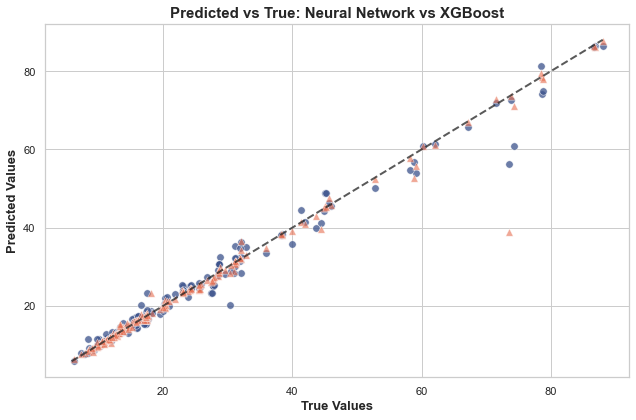

In [13]:
# --- Pretty plot: Predicted vs True values for NN and XGBoost (Nature style) ---
plt.figure(figsize=(9, 6))
# Nature color palette
color_nn = "#3B528B"      # blue-violet, for Neural Network
color_xgb = "#E76F51"     # green, for XGBoost
identity_line = "#222222" # dark, for y=x

# Plot only a random subset (e.g., 200 points) of test data for clearer visualization
subset_size = min(200, len(y_test_tensor))
subset_indices = np.random.choice(len(y_test_tensor), size=subset_size, replace=False)

# True values in original scale
y_true_subset = y_scaler.inverse_transform(y_test_tensor.cpu().numpy())[subset_indices].ravel()
# NN predictions in original scale
y_pred_nn_subset = y_scaler.inverse_transform(model_bn(X_test_tensor).detach().cpu().numpy())[subset_indices].ravel()
# XGBoost predictions in original scale
y_pred_xgb_subset = y_pred_xgb_test_orig[subset_indices]

plt.scatter(y_true_subset, y_pred_nn_subset, color=color_nn, alpha=0.75, label="Neural Network",
            edgecolor='#FFFFFF', s=55, marker='o', linewidth=0.6)
plt.scatter(y_true_subset, y_pred_xgb_subset, color=color_xgb, alpha=0.60, label="XGBoost",
            edgecolor='#FFFFFF', s=55, marker="^", linewidth=0.6)

lims = [
    min(y_true_subset.min(), y_pred_nn_subset.min(), y_pred_xgb_subset.min()), 
    max(y_true_subset.max(), y_pred_nn_subset.max(), y_pred_xgb_subset.max())
]
plt.plot(lims, lims, '--', alpha=0.75, lw=2, color=identity_line, label="Ideal (y=x)")

plt.xlabel('True Values', fontsize=13, fontweight='semibold')
plt.ylabel('Predicted Values', fontsize=13, fontweight='semibold')
plt.title('Predicted vs True: Neural Network vs XGBoost', fontsize=15, weight='bold')
# plt.legend(fontsize=12, loc='upper left', frameon=True, facecolor='#F8F5F0')
plt.tight_layout()
plt.show()

In [14]:
# Evaluate the NN MAE and R2 performance on all datasets in the original scale of total power loss

from sklearn.metrics import mean_absolute_error, r2_score

# Get predictions from the best model (in scaled space)
model_bn.eval()
with torch.no_grad():
    y_pred_train_scaled = model_bn(X_train_tensor).cpu().numpy()
    y_pred_val_scaled = model_bn(X_val_tensor).cpu().numpy()
    y_pred_test_scaled = model_bn(X_test_tensor).cpu().numpy()

# Inverse transform to original scale
y_pred_train = y_scaler.inverse_transform(y_pred_train_scaled)
y_pred_val = y_scaler.inverse_transform(y_pred_val_scaled)
y_pred_test = y_scaler.inverse_transform(y_pred_test_scaled)

y_train_true = y_scaler.inverse_transform(y_train_tensor.cpu().numpy())
y_val_true = y_scaler.inverse_transform(y_val_tensor.cpu().numpy())
y_test_true = y_scaler.inverse_transform(y_test_tensor.cpu().numpy())

# Compute MAE in original scale
mae_train = mean_absolute_error(y_train_true, y_pred_train)
mae_val = mean_absolute_error(y_val_true, y_pred_val)
mae_test = mean_absolute_error(y_test_true, y_pred_test)

# Compute R2 score in original scale
r2_train = r2_score(y_train_true, y_pred_train)
r2_val = r2_score(y_val_true, y_pred_val)
r2_test = r2_score(y_test_true, y_pred_test)

print(f"Feedforward NN (with BatchNorm) MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_train:.4f}")
print(f"  Val   MAE: {mae_val:.4f}")
print(f"  Test  MAE: {mae_test:.4f}")

print(f"Feedforward NN (with BatchNorm) R2 (Total Power Loss, original scale):")
print(f"  Train R2: {r2_train:.4f}")
print(f"  Val   R2: {r2_val:.4f}")
print(f"  Test  R2: {r2_test:.4f}")

Feedforward NN (with BatchNorm) MAE (Total Power Loss, original scale):
  Train MAE: 1.2813
  Val   MAE: 1.7079
  Test  MAE: 1.6123
Feedforward NN (with BatchNorm) R2 (Total Power Loss, original scale):
  Train R2: 0.9836
  Val   R2: 0.9661
  Test  R2: 0.9510


##### 3.2 Classic ML Models

In [15]:
# Apply Ridge Regression, SVM, and Bayesian Regression on the scaled dataset

from sklearn.linear_model import Ridge, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train_scaled.ravel())
y_pred_ridge_train = ridge.predict(X_train_scaled)
y_pred_ridge_val = ridge.predict(X_val_scaled)
y_pred_ridge_test = ridge.predict(X_test_scaled)

mse_ridge_train = mean_squared_error(y_train_scaled, y_pred_ridge_train)
mse_ridge_val = mean_squared_error(y_val_scaled, y_pred_ridge_val)
mse_ridge_test = mean_squared_error(y_test_scaled, y_pred_ridge_test)
r2_ridge_train = r2_score(y_train_scaled, y_pred_ridge_train)
r2_ridge_val = r2_score(y_val_scaled, y_pred_ridge_val)
r2_ridge_test = r2_score(y_test_scaled, y_pred_ridge_test)

print(f"Ridge Regression - Train MSE: {mse_ridge_train:.4f}, R2: {r2_ridge_train:.4f}")
print(f"Ridge Regression - Val   MSE: {mse_ridge_val:.4f}, R2: {r2_ridge_val:.4f}")
print(f"Ridge Regression - Test  MSE: {mse_ridge_test:.4f}, R2: {r2_ridge_test:.4f}")

# Support Vector Regression (SVM)
svm = SVR(kernel='rbf', C=1.0, epsilon=0.1)
svm.fit(X_train_scaled, y_train_scaled.ravel())
y_pred_svm_train = svm.predict(X_train_scaled)
y_pred_svm_val = svm.predict(X_val_scaled)
y_pred_svm_test = svm.predict(X_test_scaled)

mse_svm_train = mean_squared_error(y_train_scaled, y_pred_svm_train)
mse_svm_val = mean_squared_error(y_val_scaled, y_pred_svm_val)
mse_svm_test = mean_squared_error(y_test_scaled, y_pred_svm_test)
r2_svm_train = r2_score(y_train_scaled, y_pred_svm_train)
r2_svm_val = r2_score(y_val_scaled, y_pred_svm_val)
r2_svm_test = r2_score(y_test_scaled, y_pred_svm_test)

print(f"SVM Regression   - Train MSE: {mse_svm_train:.4f}, R2: {r2_svm_train:.4f}")
print(f"SVM Regression   - Val   MSE: {mse_svm_val:.4f}, R2: {r2_svm_val:.4f}")
print(f"SVM Regression   - Test  MSE: {mse_svm_test:.4f}, R2: {r2_svm_test:.4f}")

# Bayesian Regression
bayes = BayesianRidge()
bayes.fit(X_train_scaled, y_train_scaled.ravel())
y_pred_bayes_train = bayes.predict(X_train_scaled)
y_pred_bayes_val = bayes.predict(X_val_scaled)
y_pred_bayes_test = bayes.predict(X_test_scaled)

mse_bayes_train = mean_squared_error(y_train_scaled, y_pred_bayes_train)
mse_bayes_val = mean_squared_error(y_val_scaled, y_pred_bayes_val)
mse_bayes_test = mean_squared_error(y_test_scaled, y_pred_bayes_test)
r2_bayes_train = r2_score(y_train_scaled, y_pred_bayes_train)
r2_bayes_val = r2_score(y_val_scaled, y_pred_bayes_val)
r2_bayes_test = r2_score(y_test_scaled, y_pred_bayes_test)

print(f"Bayesian Ridge   - Train MSE: {mse_bayes_train:.4f}, R2: {r2_bayes_train:.4f}")
print(f"Bayesian Ridge   - Val   MSE: {mse_bayes_val:.4f}, R2: {r2_bayes_val:.4f}")
print(f"Bayesian Ridge   - Test  MSE: {mse_bayes_test:.4f}, R2: {r2_bayes_test:.4f}")

Ridge Regression - Train MSE: 0.7797, R2: 0.2203
Ridge Regression - Val   MSE: 0.8268, R2: 0.2169
Ridge Regression - Test  MSE: 0.7472, R2: 0.2314
SVM Regression   - Train MSE: 0.3198, R2: 0.6802
SVM Regression   - Val   MSE: 0.3267, R2: 0.6906
SVM Regression   - Test  MSE: 0.3301, R2: 0.6604
Bayesian Ridge   - Train MSE: 0.7797, R2: 0.2203
Bayesian Ridge   - Val   MSE: 0.8270, R2: 0.2168
Bayesian Ridge   - Test  MSE: 0.7473, R2: 0.2312


In [16]:
# Evaluate the MAEs of the classic ML models on the total power loss (original scale)

from sklearn.metrics import mean_absolute_error

# Inverse transform predictions and true values to original scale
# Ridge Regression
y_pred_ridge_train_orig = y_scaler.inverse_transform(y_pred_ridge_train.reshape(-1, 1))
y_pred_ridge_val_orig = y_scaler.inverse_transform(y_pred_ridge_val.reshape(-1, 1))
y_pred_ridge_test_orig = y_scaler.inverse_transform(y_pred_ridge_test.reshape(-1, 1))

# SVM Regression
y_pred_svm_train_orig = y_scaler.inverse_transform(y_pred_svm_train.reshape(-1, 1))
y_pred_svm_val_orig = y_scaler.inverse_transform(y_pred_svm_val.reshape(-1, 1))
y_pred_svm_test_orig = y_scaler.inverse_transform(y_pred_svm_test.reshape(-1, 1))

# Bayesian Ridge Regression
y_pred_bayes_train_orig = y_scaler.inverse_transform(y_pred_bayes_train.reshape(-1, 1))
y_pred_bayes_val_orig = y_scaler.inverse_transform(y_pred_bayes_val.reshape(-1, 1))
y_pred_bayes_test_orig = y_scaler.inverse_transform(y_pred_bayes_test.reshape(-1, 1))

# True values in original scale
y_train_true_orig = y_scaler.inverse_transform(y_train_scaled.reshape(-1, 1))
y_val_true_orig = y_scaler.inverse_transform(y_val_scaled.reshape(-1, 1))
y_test_true_orig = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))

# Compute MAEs
mae_ridge_train = mean_absolute_error(y_train_true_orig, y_pred_ridge_train_orig)
mae_ridge_val = mean_absolute_error(y_val_true_orig, y_pred_ridge_val_orig)
mae_ridge_test = mean_absolute_error(y_test_true_orig, y_pred_ridge_test_orig)

mae_svm_train = mean_absolute_error(y_train_true_orig, y_pred_svm_train_orig)
mae_svm_val = mean_absolute_error(y_val_true_orig, y_pred_svm_val_orig)
mae_svm_test = mean_absolute_error(y_test_true_orig, y_pred_svm_test_orig)

mae_bayes_train = mean_absolute_error(y_train_true_orig, y_pred_bayes_train_orig)
mae_bayes_val = mean_absolute_error(y_val_true_orig, y_pred_bayes_val_orig)
mae_bayes_test = mean_absolute_error(y_test_true_orig, y_pred_bayes_test_orig)

print("Ridge Regression MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_ridge_train:.4f}")
print(f"  Val   MAE: {mae_ridge_val:.4f}")
print(f"  Test  MAE: {mae_ridge_test:.4f}")

print("SVM Regression MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_svm_train:.4f}")
print(f"  Val   MAE: {mae_svm_val:.4f}")
print(f"  Test  MAE: {mae_svm_test:.4f}")

print("Bayesian Ridge Regression MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_bayes_train:.4f}")
print(f"  Val   MAE: {mae_bayes_val:.4f}")
print(f"  Test  MAE: {mae_bayes_test:.4f}")


Ridge Regression MAE (Total Power Loss, original scale):
  Train MAE: 12.0802
  Val   MAE: 12.4901
  Test  MAE: 11.5547
SVM Regression MAE (Total Power Loss, original scale):
  Train MAE: 5.6514
  Val   MAE: 5.9302
  Test  MAE: 5.5991
Bayesian Ridge Regression MAE (Total Power Loss, original scale):
  Train MAE: 12.0836
  Val   MAE: 12.4952
  Test  MAE: 11.5599


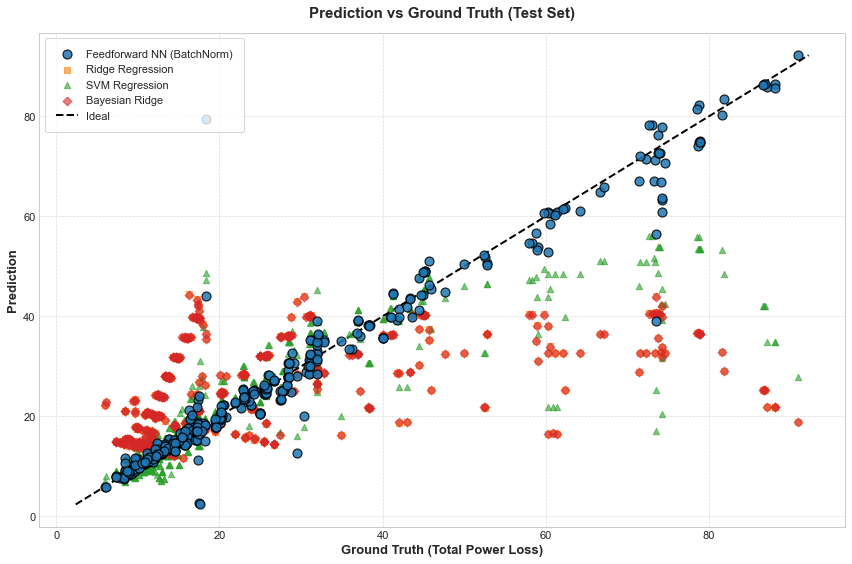

In [17]:
import matplotlib.pyplot as plt

# Prepare ground truth and predictions for all models (test set)
# y_test_true: NN, y_test_true_orig: classic ML (should be the same)
y_true = y_test_true.flatten()
y_pred_nn = y_pred_test.flatten()
y_pred_ridge = y_pred_ridge_test_orig.flatten()
y_pred_svm = y_pred_svm_test_orig.flatten()
y_pred_bayes = y_pred_bayes_test_orig.flatten()

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(12, 8))

# Make FNN stand out: larger markers, distinct color, edge, and zorder
ax.scatter(
    y_true, y_pred_nn,
    label='Feedforward NN (BatchNorm)',
    alpha=0.85, s=80, c='#1f77b4', edgecolor='black', linewidth=1.2, marker='o', zorder=3
)

# Other models: muted colors, smaller markers
ax.scatter(
    y_true, y_pred_ridge,
    label='Ridge Regression',
    alpha=0.6, s=40, c='#ff7f0e', marker='s', zorder=2
)
ax.scatter(
    y_true, y_pred_svm,
    label='SVM Regression',
    alpha=0.6, s=40, c='#2ca02c', marker='^', zorder=2
)
ax.scatter(
    y_true, y_pred_bayes,
    label='Bayesian Ridge',
    alpha=0.6, s=40, c='#d62728', marker='D', zorder=2
)

# Plot y=x line for reference
min_val = min(y_true.min(), y_pred_nn.min(), y_pred_ridge.min(), y_pred_svm.min(), y_pred_bayes.min())
max_val = max(y_true.max(), y_pred_nn.max(), y_pred_ridge.max(), y_pred_svm.max(), y_pred_bayes.max())
ax.plot(
    [min_val, max_val], [min_val, max_val],
    'k--', lw=2, label='Ideal', zorder=1
)

ax.set_xlabel('Ground Truth (Total Power Loss)', fontsize=13, fontweight='bold')
ax.set_ylabel('Prediction', fontsize=13, fontweight='bold')
ax.set_title('Prediction vs Ground Truth (Test Set)', fontsize=15, fontweight='bold', pad=15)
ax.legend(frameon=True, fontsize=11, loc='upper left', borderpad=1)
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()


##### 3.3 Ensemble Learning Models

In [18]:
# Random Forest Regression
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_scaled.ravel())
y_pred_rf_train = rf.predict(X_train_scaled)
y_pred_rf_val = rf.predict(X_val_scaled)
y_pred_rf_test = rf.predict(X_test_scaled)

mse_rf_train = mean_squared_error(y_train_scaled, y_pred_rf_train)
mse_rf_val = mean_squared_error(y_val_scaled, y_pred_rf_val)
mse_rf_test = mean_squared_error(y_test_scaled, y_pred_rf_test)
r2_rf_train = r2_score(y_train_scaled, y_pred_rf_train)
r2_rf_val = r2_score(y_val_scaled, y_pred_rf_val)
r2_rf_test = r2_score(y_test_scaled, y_pred_rf_test)

print(f"Random Forest    - Train MSE: {mse_rf_train:.4f}, R2: {r2_rf_train:.4f}")
print(f"Random Forest    - Val   MSE: {mse_rf_val:.4f}, R2: {r2_rf_val:.4f}")
print(f"Random Forest    - Test  MSE: {mse_rf_test:.4f}, R2: {r2_rf_test:.4f}")

# XGBoost Regression
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train_scaled.ravel())
y_pred_xgb_train = xgb.predict(X_train_scaled)
y_pred_xgb_val = xgb.predict(X_val_scaled)
y_pred_xgb_test = xgb.predict(X_test_scaled)

mse_xgb_train = mean_squared_error(y_train_scaled, y_pred_xgb_train)
mse_xgb_val = mean_squared_error(y_val_scaled, y_pred_xgb_val)
mse_xgb_test = mean_squared_error(y_test_scaled, y_pred_xgb_test)
r2_xgb_train = r2_score(y_train_scaled, y_pred_xgb_train)
r2_xgb_val = r2_score(y_val_scaled, y_pred_xgb_val)
r2_xgb_test = r2_score(y_test_scaled, y_pred_xgb_test)

print(f"XGBoost          - Train MSE: {mse_xgb_train:.4f}, R2: {r2_xgb_train:.4f}")
print(f"XGBoost          - Val   MSE: {mse_xgb_val:.4f}, R2: {r2_xgb_val:.4f}")
print(f"XGBoost          - Test  MSE: {mse_xgb_test:.4f}, R2: {r2_xgb_test:.4f}")


Random Forest    - Train MSE: 0.0031, R2: 0.9969
Random Forest    - Val   MSE: 0.0167, R2: 0.9842
Random Forest    - Test  MSE: 0.0215, R2: 0.9779
XGBoost          - Train MSE: 0.0001, R2: 0.9999
XGBoost          - Val   MSE: 0.0332, R2: 0.9686
XGBoost          - Test  MSE: 0.0287, R2: 0.9705


In [19]:
# Evaluate the Random Forest and XGBoost MAE performance on all datasets in the original scale of total power loss

from sklearn.metrics import mean_absolute_error

# Get predictions from Random Forest and XGBoost (in scaled space)
y_pred_rf_train_scaled = y_pred_rf_train.reshape(-1, 1)
y_pred_rf_val_scaled = y_pred_rf_val.reshape(-1, 1)
y_pred_rf_test_scaled = y_pred_rf_test.reshape(-1, 1)

y_pred_xgb_train_scaled = y_pred_xgb_train.reshape(-1, 1)
y_pred_xgb_val_scaled = y_pred_xgb_val.reshape(-1, 1)
y_pred_xgb_test_scaled = y_pred_xgb_test.reshape(-1, 1)

# Inverse transform to original scale
y_pred_rf_train = y_scaler.inverse_transform(y_pred_rf_train_scaled)
y_pred_rf_val = y_scaler.inverse_transform(y_pred_rf_val_scaled)
y_pred_rf_test = y_scaler.inverse_transform(y_pred_rf_test_scaled)

y_pred_xgb_train = y_scaler.inverse_transform(y_pred_xgb_train_scaled)
y_pred_xgb_val = y_scaler.inverse_transform(y_pred_xgb_val_scaled)
y_pred_xgb_test = y_scaler.inverse_transform(y_pred_xgb_test_scaled)

y_train_true = y_scaler.inverse_transform(y_train_scaled.reshape(-1, 1))
y_val_true = y_scaler.inverse_transform(y_val_scaled.reshape(-1, 1))
y_test_true = y_scaler.inverse_transform(y_test_scaled.reshape(-1, 1))

# Compute MAE in original scale for Random Forest
mae_rf_train = mean_absolute_error(y_train_true, y_pred_rf_train)
mae_rf_val = mean_absolute_error(y_val_true, y_pred_rf_val)
mae_rf_test = mean_absolute_error(y_test_true, y_pred_rf_test)

print(f"Random Forest MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_rf_train:.4f}")
print(f"  Val   MAE: {mae_rf_val:.4f}")
print(f"  Test  MAE: {mae_rf_test:.4f}")

# Compute MAE in original scale for XGBoost
mae_xgb_train = mean_absolute_error(y_train_true, y_pred_xgb_train)
mae_xgb_val = mean_absolute_error(y_val_true, y_pred_xgb_val)
mae_xgb_test = mean_absolute_error(y_test_true, y_pred_xgb_test)

print(f"XGBoost MAE (Total Power Loss, original scale):")
print(f"  Train MAE: {mae_xgb_train:.4f}")
print(f"  Val   MAE: {mae_xgb_val:.4f}")
print(f"  Test  MAE: {mae_xgb_test:.4f}")


Random Forest MAE (Total Power Loss, original scale):
  Train MAE: 0.2377
  Val   MAE: 0.6758
  Test  MAE: 0.6416
XGBoost MAE (Total Power Loss, original scale):
  Train MAE: 0.1068
  Val   MAE: 0.7852
  Test  MAE: 0.6997


##### 3.4 Ensemble Learning Models for all Objectives
* Ensemble learning achieves the best accuracy on power loss modeling, so is adopted for voltage and current ripples modeling

In [20]:
# XGBoost Regression for all objectives: power loss, current ripple, voltage ripple
from xgboost import XGBRegressor

# --- Power Loss ---
xgb_loss = XGBRegressor(
    n_estimators=1000,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=20
)
xgb_loss.fit(
    X_train, y_loss_train.ravel(),
    eval_set=[(X_val, y_loss_val.ravel())],
    eval_metric="rmse",
    verbose=False
)
y_pred_xgb_train_loss = xgb_loss.predict(X_train)
y_pred_xgb_val_loss = xgb_loss.predict(X_val)
y_pred_xgb_test_loss = xgb_loss.predict(X_test)

mse_xgb_train_loss = mean_squared_error(y_loss_train, y_pred_xgb_train_loss)
mse_xgb_val_loss = mean_squared_error(y_loss_val, y_pred_xgb_val_loss)
mse_xgb_test_loss = mean_squared_error(y_loss_test, y_pred_xgb_test_loss)
r2_xgb_train_loss = r2_score(y_loss_train, y_pred_xgb_train_loss)
r2_xgb_val_loss = r2_score(y_loss_val, y_pred_xgb_val_loss)
r2_xgb_test_loss = r2_score(y_loss_test, y_pred_xgb_test_loss)

print(f"XGBoost (Power Loss)          - Train MSE: {mse_xgb_train_loss:.4f}, R2: {r2_xgb_train_loss:.4f}")
print(f"XGBoost (Power Loss)          - Val   MSE: {mse_xgb_val_loss:.4f}, R2: {r2_xgb_val_loss:.4f}")
print(f"XGBoost (Power Loss)          - Test  MSE: {mse_xgb_test_loss:.4f}, R2: {r2_xgb_test_loss:.4f}")

# --- Current Ripple ---
xgb_current = XGBRegressor(
    n_estimators=1000,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=20
)
xgb_current.fit(
    X_train, y_current_ripple_train.reshape(-1),
    eval_set=[(X_val, y_current_ripple_val.reshape(-1))],
    eval_metric="rmse",
    verbose=False
)
y_pred_xgb_train_current = xgb_current.predict(X_train)
y_pred_xgb_val_current = xgb_current.predict(X_val)
y_pred_xgb_test_current = xgb_current.predict(X_test)

mse_xgb_train_current = mean_squared_error(y_current_ripple_train, y_pred_xgb_train_current)
mse_xgb_val_current = mean_squared_error(y_current_ripple_val, y_pred_xgb_val_current)
mse_xgb_test_current = mean_squared_error(y_current_ripple_test, y_pred_xgb_test_current)
r2_xgb_train_current = r2_score(y_current_ripple_train, y_pred_xgb_train_current)
r2_xgb_val_current = r2_score(y_current_ripple_val, y_pred_xgb_val_current)
r2_xgb_test_current = r2_score(y_current_ripple_test, y_pred_xgb_test_current)

print(f"XGBoost (Current Ripple)      - Train MSE: {mse_xgb_train_current:.4f}, R2: {r2_xgb_train_current:.4f}")
print(f"XGBoost (Current Ripple)      - Val   MSE: {mse_xgb_val_current:.4f}, R2: {r2_xgb_val_current:.4f}")
print(f"XGBoost (Current Ripple)      - Test  MSE: {mse_xgb_test_current:.4f}, R2: {r2_xgb_test_current:.4f}")

# --- Voltage Ripple ---
xgb_voltage = XGBRegressor(
    n_estimators=1000,
    random_state=42,
    verbosity=0,
    early_stopping_rounds=20
)
xgb_voltage.fit(
    X_train, y_voltage_ripple_train.reshape(-1),
    eval_set=[(X_val, y_voltage_ripple_val.reshape(-1))],
    eval_metric="rmse",
    verbose=False
)
y_pred_xgb_train_voltage = xgb_voltage.predict(X_train)
y_pred_xgb_val_voltage = xgb_voltage.predict(X_val)
y_pred_xgb_test_voltage = xgb_voltage.predict(X_test)

mse_xgb_train_voltage = mean_squared_error(y_voltage_ripple_train, y_pred_xgb_train_voltage)
mse_xgb_val_voltage = mean_squared_error(y_voltage_ripple_val, y_pred_xgb_val_voltage)
mse_xgb_test_voltage = mean_squared_error(y_voltage_ripple_test, y_pred_xgb_test_voltage)
r2_xgb_train_voltage = r2_score(y_voltage_ripple_train, y_pred_xgb_train_voltage)
r2_xgb_val_voltage = r2_score(y_voltage_ripple_val, y_pred_xgb_val_voltage)
r2_xgb_test_voltage = r2_score(y_voltage_ripple_test, y_pred_xgb_test_voltage)

print(f"XGBoost (Voltage Ripple)      - Train MSE: {mse_xgb_train_voltage:.4f}, R2: {r2_xgb_train_voltage:.4f}")
print(f"XGBoost (Voltage Ripple)      - Val   MSE: {mse_xgb_val_voltage:.4f}, R2: {r2_xgb_val_voltage:.4f}")
print(f"XGBoost (Voltage Ripple)      - Test  MSE: {mse_xgb_test_voltage:.4f}, R2: {r2_xgb_test_voltage:.4f}")

XGBoost (Power Loss)          - Train MSE: 0.0001, R2: 1.0000
XGBoost (Power Loss)          - Val   MSE: 8.5187, R2: 0.9780
XGBoost (Power Loss)          - Test  MSE: 12.0297, R2: 0.9663
XGBoost (Current Ripple)      - Train MSE: 0.0000, R2: 0.9997
XGBoost (Current Ripple)      - Val   MSE: 0.0001, R2: 0.9807
XGBoost (Current Ripple)      - Test  MSE: 0.0001, R2: 0.9780
XGBoost (Voltage Ripple)      - Train MSE: 0.0000, R2: 0.9993
XGBoost (Voltage Ripple)      - Val   MSE: 0.0001, R2: 0.8755
XGBoost (Voltage Ripple)      - Test  MSE: 0.0001, R2: 0.8905


#### 4 Stage 3: Meta-Heuristic Algorithms Interact with Data-Driven Models to Optimize Buck Converter Performances
   1. Compare PSO and GA
   2. Multi-Objective design with non-dominated sorting

##### 4.1 Define Objective Functions

In [21]:
def Vol(fs, L_idx, C_idx):
    """
    Calculate the volume of inductor and capacitor components.

    Args:
        fs (float): Switching frequency (not used here, but kept for interface consistency)
        L_idx (int): Index of inductor in L_list_available
        C_idx (int): Index of capacitor combination in C_combinations

    Returns:
        tuple: (VolumeL, VolumeC) - Volume of inductor and total volume of capacitors
    """
    func_VolC = lambda x0: sum(list(map(Volume_C.get, x0)))
    VolumeC = func_VolC(C_combinations[C_idx])
    VolumeL = VolL_list_available[L_idx]
    return VolumeL, VolumeC

def total_power_loss(fs, L_idx, C_idx):
    """
    Predict the total power loss of the converter for given fs, L, and C values using the XGBoost model.

    Args:
        fs (float): Switching frequency (continuous variable)
        L_idx (int): Index of inductor in L_list_available
        C_idx (int): Index of capacitor combination in C_combinations

    Returns:
        float: Predicted total power loss (normalized or in appropriate units)
    """
    L = L_list_available[L_idx]
    # Use C_available and C_idx as in file_context_0
    C_total = C_available[C_idx]
    X_pred = np.array([[fs, L, C_total]])
    loss_pred = xgb_loss.predict(X_pred)[0]  # Predict power loss
    return loss_pred

def current_ripple(fs, L_idx, C_idx):
    """
    Calculate the inductor current ripple for given fs, L, and C values using the XGBoost model.

    Args:
        fs (float): Switching frequency (continuous variable)
        L_idx (int): Index of inductor in L_list_available
        C_idx (int): Index of capacitor combination in C_combinations

    Returns:
        float: Inductor current ripple in amperes
    """
    L = L_list_available[L_idx]
    C_total = C_available[C_idx]
    X_pred = np.array([[fs, L, C_total]])
    ripple = xgb_current.predict(X_pred)[0]
    return ripple

def voltage_ripple(fs, L_idx, C_idx):
    """
    Calculate the output voltage ripple for given fs, L, and C values using the XGBoost model.

    Args:
        fs (float): Switching frequency (continuous variable)
        L_idx (int): Index of inductor in L_list_available
        C_idx (int): Index of capacitor combination in C_combinations

    Returns:
        float: Output voltage ripple in volts
    """
    L = L_list_available[L_idx]
    C_total = C_available[C_idx]
    X_pred = np.array([[fs, L, C_total]])
    v_ripple = xgb_voltage.predict(X_pred)[0]
    return v_ripple

def fitness_func(solution, solution_idx, vol_lim=7.0, i_ripple_lim=0.10, v_ripple_lim=0.01):
    """
    Fitness function for genetic algorithm to minimize total power loss while respecting volume, current ripple, and voltage ripple constraints.

    Args:
        solution (numpy.ndarray): Array containing [fs, L_idx, C_idx]
        solution_idx (int): Index of the solution in the population
        vol_lim (float): Maximum allowed total volume in cm3
        i_ripple_lim (float): Maximum allowed current ripple (absolute value, e.g., 0.1 for 10%)
        v_ripple_lim (float): Maximum allowed voltage ripple (absolute value, e.g., 0.01 for 1%)

    Returns:
        float: Fitness value (higher is better)
    """
    # Extract variables from solution
    fs = float(solution[0])
    L_idx = int(solution[1])
    C_idx = int(solution[2])

    # Calculate metrics
    loss = total_power_loss(fs, L_idx, C_idx)
    i_ripple = current_ripple(fs, L_idx, C_idx)
    v_ripple = voltage_ripple(fs, L_idx, C_idx)
    volL, volC = Vol(fs, L_idx, C_idx)
    total_vol = volL + volC

    # Check constraints
    if total_vol > vol_lim:
        return 1e-6  # Penalize solutions exceeding volume limit
    if i_ripple > i_ripple_lim:
        return 1e-6  # Penalize solutions exceeding current ripple limit
    if v_ripple > v_ripple_lim:
        return 1e-6  # Penalize solutions exceeding voltage ripple limit

    # Fitness: minimize total power loss (higher fitness for lower loss)
    # Add a small constant to denominator to avoid division by zero
    fitness = 100 / (100 + loss + 1e-6)
    return fitness

##### 4.2 Implement GA and PSO

d:\Anaconda\lib\site-packages\pygad\pygad.py:1139: UserWarning: The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.
  warnings.warn("The 'delay_after_gen' parameter is deprecated starting from PyGAD 3.3.0. To delay or pause the evolution after each generation, assign a callback function/method to the 'on_generation' parameter to adds some time delay.")
d:\Anaconda\lib\site-packages\pygad\pygad.py:1153: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
d:\Anaconda\lib\site-packages\pygad\pygad.py:1162: UserWarning: Use the 'save_solutions' p

Best switching frequency (fs): 45.41 kHz
Best L value: 291.65 µH
Inductor core part number: T-106-75-200
Inductor number of turns: 56
Inductor volume: 6.31 cm³
Best C value: 220.00 µF
Capacitor bank combination: [0.00022]
Capacitor volume: 0.58 cm³
Total volume: 6.89 cm³
Final total power loss: 8.4978
Final current ripple: 9.50%
Final voltage ripple: 0.67%
Fitness: 0.921678


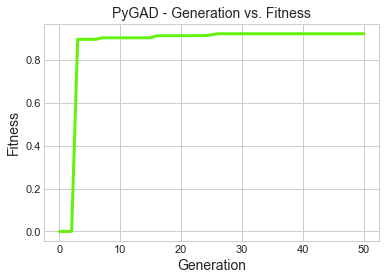

In [22]:
import pygad
import numpy as np

# Define the gene space for fs, L_idx, and C_idx
gene_space = [
    {'low': 10000, 'high': 60000},  # fs in Hz (20 kHz to 100 kHz)
    list(range(len(L_list_available))),  # L_idx
    list(range(len(C_combinations)))     # C_idx
]

# Set random seed for reproducibility
np.random.seed(42)

# Create GA instance
pop_size = 12
ga_instance = pygad.GA(
    num_generations=50,
    num_parents_mating=4,
    # Use lambda to pass the required arguments to fitness_func
    fitness_func=lambda ga_instance, solution, solution_idx: fitness_func(solution, solution_idx, vol_lim=7, i_ripple_lim=0.1, v_ripple_lim=0.01),
    sol_per_pop=pop_size,
    num_genes=3,
    gene_space=gene_space,
    mutation_type="random",
    mutation_percent_genes=40,
    random_seed=42,
    save_solutions=True,
    save_best_solutions=True,
)

# Run the GA
ga_instance.run()

# Get the best solution
solution, solution_fitness, solution_idx = ga_instance.best_solution()

# Extract variables from solution
fs_best = float(solution[0])
L_idx_best = int(solution[1])
C_idx_best = int(solution[2])

# Calculate final metrics
final_loss = total_power_loss(fs_best, L_idx_best, C_idx_best)
final_i_ripple = current_ripple(fs_best, L_idx_best, C_idx_best)
final_v_ripple = voltage_ripple(fs_best, L_idx_best, C_idx_best)
volL, volC = Vol(fs_best, L_idx_best, C_idx_best)
total_vol = volL + volC

# Print results
print(f"Best switching frequency (fs): {fs_best/1000:.2f} kHz")
print(f"Best L value: {L_list_available[L_idx_best]*1e6:.2f} µH")
print(f"Inductor core part number: {core_list_available[L_idx_best]}")
print(f"Inductor number of turns: {N_list_available[L_idx_best]}")
print(f"Inductor volume: {VolL_list_available[L_idx_best]:.2f} cm³")
print(f"Best C value: {C_available[C_idx_best]*1e6:.2f} µF")
print(f"Capacitor bank combination: {C_combinations[C_idx_best]}")
print(f"Capacitor volume: {volC:.2f} cm³")
print(f"Total volume: {total_vol:.2f} cm³")
print(f"Final total power loss: {final_loss:.4f}")
print(f"Final current ripple: {final_i_ripple*100:.2f}%")
print(f"Final voltage ripple: {final_v_ripple*100:.2f}%")
print(f"Fitness: {solution_fitness:.6f}")

# Plot the fitness over generations
ga_instance.plot_fitness()
plt.show()

Iteration 1/50, Cost: -1e-06
Iteration 2/50, Cost: -1e-06
Iteration 3/50, Cost: -1e-06
Iteration 4/50, Cost: -1e-06
Iteration 5/50, Cost: -1e-06
Iteration 6/50, Cost: -1e-06
Iteration 7/50, Cost: -1e-06
Iteration 8/50, Cost: -0.9246269057393541
Iteration 9/50, Cost: -0.9246269057393541
Iteration 10/50, Cost: -0.9246269057393541
Iteration 11/50, Cost: -0.9246269057393541
Iteration 12/50, Cost: -0.9246269057393541
Iteration 13/50, Cost: -0.9246269057393541
Iteration 14/50, Cost: -0.9246269057393541
Iteration 15/50, Cost: -0.9246269057393541
Iteration 16/50, Cost: -0.9246269057393541
Iteration 17/50, Cost: -0.9246269057393541
Iteration 18/50, Cost: -0.9246269057393541
Iteration 19/50, Cost: -0.9246269057393541
Iteration 20/50, Cost: -0.9246269057393541
Iteration 21/50, Cost: -0.9246269057393541
Iteration 22/50, Cost: -0.9246269057393541
Iteration 23/50, Cost: -0.9246269057393541
Iteration 24/50, Cost: -0.9246269057393541
Iteration 25/50, Cost: -0.9246269057393541
Iteration 26/50, Cost: -0

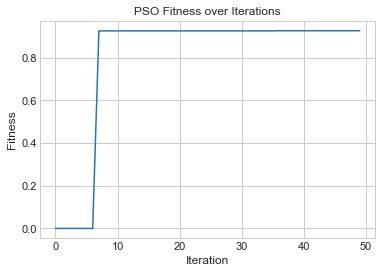

In [23]:
import pyswarms as ps
import numpy as np

# Define the bounds for the variables
# fs: [min_fs, max_fs], L_idx: [0, len(L_list_available)-1], C_idx: [0, len(C_combinations)-1]
min_fs = gene_space[0]['low']
max_fs = gene_space[0]['high']
min_L_idx = 0
max_L_idx = len(L_list_available) - 1
min_C_idx = 0
max_C_idx = len(C_combinations) - 1

# Lower and upper bounds for each variable
lb = [min_fs, min_L_idx, min_C_idx]
ub = [max_fs, max_L_idx, max_C_idx]
bounds = (np.array(lb), np.array(ub))

# Define the fitness function for PSO (it should return -fitness for minimization)
def pso_fitness(X):
    # X is shape (n_particles, n_dimensions)
    fitness_vals = []
    for sol in X:
        # Round L_idx and C_idx to nearest integer and clip to valid range
        fs = float(sol[0])
        L_idx = int(np.clip(np.round(sol[1]), min_L_idx, max_L_idx))
        C_idx = int(np.clip(np.round(sol[2]), min_C_idx, max_C_idx))
        fitness = fitness_func([fs, L_idx, C_idx], 0)
        # Since pyswarms minimizes, return negative fitness
        fitness_vals.append(-fitness)
    return np.array(fitness_vals)

# Set up the optimizer with initial options (w will be updated each iteration)
options = {'c1': 2.05, 'c2': 2.05, 'w': 0.9}
optimizer = ps.single.GlobalBestPSO(
    n_particles=12,
    dimensions=3,
    options=options,
    bounds=bounds
)

# Linearly decrease inertia weight from 0.9 to 0.1 over 50 iterations
n_iters = 50
w_start = 0.9
w_end = 0.1
w_schedule = np.linspace(w_start, w_end, n_iters)

# Custom optimization loop to update inertia weight each iteration
cost_history = []
for i in range(n_iters):
    optimizer.options['w'] = w_schedule[i]
    cost, pos = optimizer.optimize(pso_fitness, iters=1, verbose=False)
    cost_history.append(cost)
    print(f"Iteration {i+1}/{n_iters}, Cost: {cost}")

# Store cost history for plotting
optimizer.cost_history = cost_history

# Extract best solution
fs_pso = float(pos[0])
L_idx_pso = int(np.clip(np.round(pos[1]), min_L_idx, max_L_idx))
C_idx_pso = int(np.clip(np.round(pos[2]), min_C_idx, max_C_idx))

# Calculate final metrics for PSO solution
final_loss_pso = total_power_loss(fs_pso, L_idx_pso, C_idx_pso)
final_i_ripple_pso = current_ripple(fs_pso, L_idx_pso, C_idx_pso)
final_v_ripple_pso = voltage_ripple(fs_pso, L_idx_pso, C_idx_pso)
volL_pso, volC_pso = Vol(fs_pso, L_idx_pso, C_idx_pso)
total_vol_pso = volL_pso + volC_pso
fitness_pso = fitness_func([fs_pso, L_idx_pso, C_idx_pso], 0)

# Print PSO results
print("\n--- PSO Optimization Results ---")
print(f"Best switching frequency (fs): {fs_pso/1000:.2f} kHz")
print(f"Best L value: {L_list_available[L_idx_pso]*1e6:.2f} µH")
print(f"Inductor core part number: {core_list_available[L_idx_pso]}")
print(f"Inductor number of turns: {N_list_available[L_idx_pso]}")
print(f"Inductor volume: {VolL_list_available[L_idx_pso]:.2f} cm³")
print(f"Best C value: {C_available[C_idx_pso]*1e6:.2f} µF")
print(f"Capacitor bank combination: {C_combinations[C_idx_pso]}")
print(f"Capacitor volume: {volC_pso:.2f} cm³")
print(f"Total volume: {total_vol_pso:.2f} cm³")
print(f"Final total power loss: {final_loss_pso:.4f}")
print(f"Final current ripple: {final_i_ripple_pso*100:.2f}%")
print(f"Final voltage ripple: {final_v_ripple_pso*100:.2f}%")
print(f"Fitness: {fitness_pso:.6f}")

# Plot PSO cost history
import matplotlib.pyplot as plt
plt.figure()
plt.plot(-np.array(optimizer.cost_history))
plt.xlabel('Iteration')
plt.ylabel('Fitness')
plt.title('PSO Fitness over Iterations')
plt.grid(True)
plt.show()


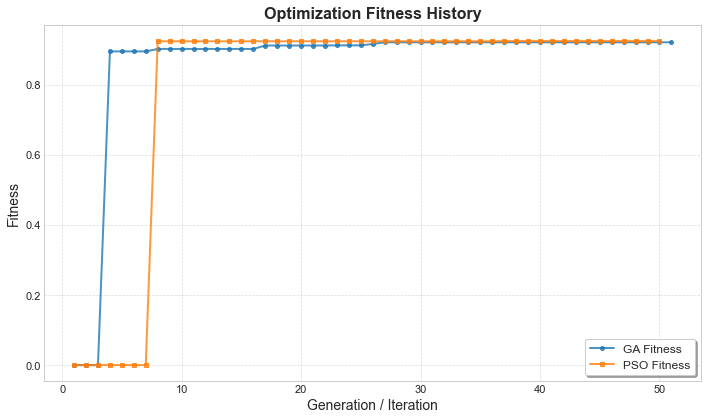

In [24]:
# Plot both GA and PSO optimization histories in one professionally styled figure

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Plot GA fitness history (if available)
if hasattr(ga_instance, "best_solutions_fitness"):
    ga_fitness = ga_instance.best_solutions_fitness
    plt.plot(
        range(1, len(ga_fitness) + 1),
        ga_fitness,
        label="GA Fitness",
        color="tab:blue",
        linewidth=2,
        marker='o',
        markersize=4,
        alpha=0.8
    )

# Plot PSO fitness history (cost_history is negative fitness)
if hasattr(optimizer, "cost_history"):
    pso_fitness = -np.array(optimizer.cost_history)
    plt.plot(
        range(1, len(pso_fitness) + 1),
        pso_fitness,
        label="PSO Fitness",
        color="tab:orange",
        linewidth=2,
        marker='s',
        markersize=4,
        alpha=0.8
    )

plt.title("Optimization Fitness History", fontsize=16, fontweight='bold')
plt.xlabel("Generation / Iteration", fontsize=14)
plt.ylabel("Fitness", fontsize=14)
plt.legend(fontsize=12, loc='best', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)
plt.tight_layout()
plt.show()
